# Simple Stable Diffusion on MNIST

## Imports & config

In [1]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from matplotlib import gridspec

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

IMG_SIZE   = 28
IMG_CH     = 1
NUM_CLASSES = 10
T          = 1000
BETA_START = 1e-4
BETA_END   = 2e-2
BATCH_SIZE = 128
LR         = 2e-4
EPOCHS     = 50
EMB_DIM    = 128
OUT_DIR    = "out_diffusion"
os.makedirs(OUT_DIR, exist_ok=True)

Using device: cuda


## Data loading

In [2]:
from torch.utils.data import random_split

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),   # [0,1] -> [-1,1]
])

full_train = datasets.MNIST(root="../MNIST", train=True,  download=True, transform=transform)
test_set   = datasets.MNIST(root="../MNIST", train=False, download=True, transform=transform)

train_set, val_set = random_split(
    full_train, [55_000, 5_000],
    generator=torch.Generator().manual_seed(42),
)

lk = dict(num_workers=2, pin_memory=(device.type == "cuda"))
train_loader = DataLoader(train_set, BATCH_SIZE, shuffle=True, drop_last=True, **lk)
val_loader   = DataLoader(val_set,   BATCH_SIZE, **lk)
test_loader  = DataLoader(test_set,  BATCH_SIZE, **lk)

x, y = next(iter(train_loader))
print(f"sizes: train={len(train_set)} val={len(val_set)} test={len(test_set)}")
print(f"batch: {tuple(x.shape)}  range=[{x.min():.2f}, {x.max():.2f}]")

sizes: train=55000 val=5000 test=10000
batch: (128, 1, 28, 28)  range=[-1.00, 1.00]


## Noise schedule

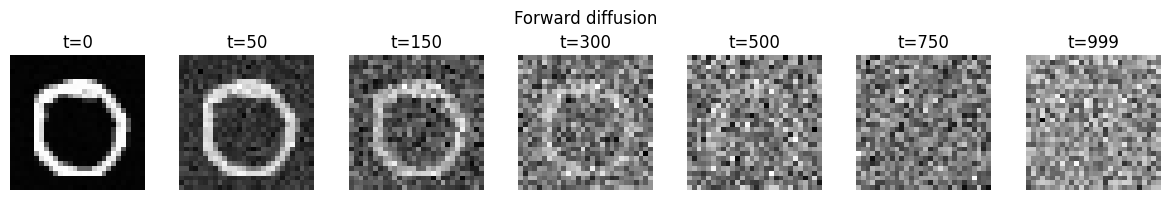

In [3]:
betas = torch.linspace(BETA_START, BETA_END, T, device=device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod           = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas  = torch.sqrt(1.0 / alphas)
posterior_variance = betas


def extract(arr, t, x_shape):
    return arr.gather(0, t).view(-1, *([1] * (len(x_shape) - 1)))


def q_sample(x_0, t, noise):
    return (extract(sqrt_alphas_cumprod,           t, x_0.shape) * x_0
          + extract(sqrt_one_minus_alphas_cumprod, t, x_0.shape) * noise)


x0, _ = next(iter(train_loader))
x0 = x0[:1].to(device)
steps = [0, 50, 150, 300, 500, 750, 999]
fig, axes = plt.subplots(1, len(steps), figsize=(12, 2))
for ax, s in zip(axes, steps):
    xt = q_sample(x0, torch.tensor([s], device=device), torch.randn_like(x0))
    ax.imshow(xt.squeeze().cpu(), cmap="gray"); ax.set_title(f"t={s}"); ax.axis("off")
plt.suptitle("Forward diffusion"); plt.tight_layout(); plt.show()

## Conditional U-Net

In [4]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.emb_proj(F.silu(emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class CondUNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, emb_dim=EMB_DIM, C=32):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(emb_dim),
            nn.Linear(emb_dim, emb_dim), nn.SiLU(), nn.Linear(emb_dim, emb_dim),
        )
        self.class_embed = nn.Embedding(num_classes, emb_dim)

        self.stem  = nn.Conv2d(IMG_CH, C, 3, padding=1)
        self.d1    = ResBlock(C,     C,     emb_dim)
        self.down1 = nn.Conv2d(C,     C,     3, stride=2, padding=1)
        self.d2    = ResBlock(C,     2 * C, emb_dim)
        self.down2 = nn.Conv2d(2*C,  2*C,   3, stride=2, padding=1)

        self.m1 = ResBlock(2*C, 2*C, emb_dim)
        self.m2 = ResBlock(2*C, 2*C, emb_dim)

        self.u2 = ResBlock(4*C, 2*C, emb_dim)
        self.u1 = ResBlock(3*C,  C,  emb_dim)
        self.out = nn.Sequential(
            nn.GroupNorm(8, C), nn.SiLU(),
            nn.Conv2d(C, IMG_CH, 3, padding=1),
        )

    def forward(self, x, t, y):
        emb = self.time_mlp(t) + self.class_embed(y)

        x  = self.stem(x)
        h1 = self.d1(x, emb)
        h2 = self.d2(self.down1(h1), emb)
        x  = self.m2(self.m1(self.down2(h2), emb), emb)

        up = lambda z: F.interpolate(z, scale_factor=2, mode="nearest")
        x = self.u2(torch.cat([up(x), h2], dim=1), emb)
        x = self.u1(torch.cat([up(x), h1], dim=1), emb)
        return self.out(x)


model = CondUNet().to(device)
print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Params: 506,657


## Training loop

Epoch   1/50 | train 0.1075 | val 0.0477 | 16.1s
Epoch   2/50 | train 0.0414 | val 0.0380 | 16.0s
Epoch   3/50 | train 0.0345 | val 0.0332 | 16.2s
Epoch   4/50 | train 0.0314 | val 0.0299 | 15.0s
Epoch   5/50 | train 0.0300 | val 0.0294 | 16.5s
Epoch   6/50 | train 0.0283 | val 0.0295 | 16.0s
Epoch   7/50 | train 0.0276 | val 0.0286 | 16.0s
Epoch   8/50 | train 0.0267 | val 0.0263 | 16.1s
Epoch   9/50 | train 0.0262 | val 0.0259 | 15.8s
Epoch  10/50 | train 0.0261 | val 0.0259 | 16.3s
Epoch  11/50 | train 0.0255 | val 0.0254 | 16.1s
Epoch  12/50 | train 0.0250 | val 0.0243 | 14.9s
Epoch  13/50 | train 0.0247 | val 0.0248 | 16.4s
Epoch  14/50 | train 0.0245 | val 0.0244 | 16.4s
Epoch  15/50 | train 0.0243 | val 0.0240 | 15.7s
Epoch  16/50 | train 0.0241 | val 0.0247 | 16.4s
Epoch  17/50 | train 0.0238 | val 0.0243 | 16.2s
Epoch  18/50 | train 0.0240 | val 0.0237 | 16.3s
Epoch  19/50 | train 0.0239 | val 0.0240 | 16.0s
Epoch  20/50 | train 0.0236 | val 0.0245 | 16.2s
Epoch  21/50 | train

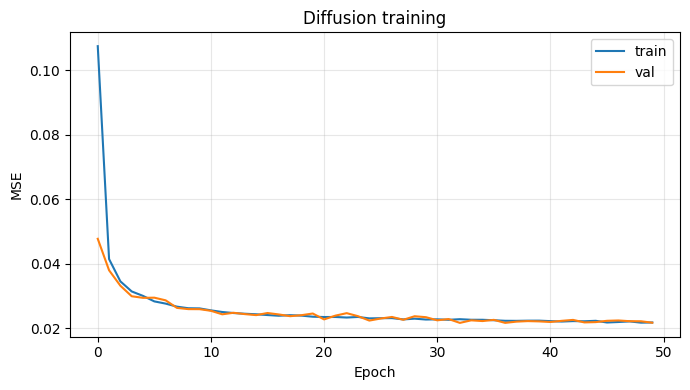

In [5]:
import time
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def loss_step(model, x_0, y):
    t = torch.randint(0, T, (x_0.size(0),), device=device)
    noise = torch.randn_like(x_0)
    return F.mse_loss(model(q_sample(x_0, t, noise), t, y), noise)

@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    total, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        total += loss_step(model, x, y).item() * x.size(0)
        n += x.size(0)
    model.train()
    return total / n

history = {"train": [], "val": []}
for epoch in range(1, EPOCHS + 1):
    model.train(); running, n_seen, t0 = 0.0, 0, time.time()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = loss_step(model, x, y)
        loss.backward(); optimizer.step()
        running += loss.item() * x.size(0); n_seen += x.size(0)

    train_l = running / n_seen
    val_l   = eval_loss(model, val_loader)
    history["train"].append(train_l); history["val"].append(val_l)
    print(f"Epoch {epoch:3d}/{EPOCHS} | train {train_l:.4f} | val {val_l:.4f} | {time.time()-t0:.1f}s")

    if epoch % 5 == 0 or epoch == EPOCHS:
        torch.save(
            {"epoch": epoch, "model_state": model.state_dict(), "history": history},
            os.path.join(OUT_DIR, f"ckpt_{epoch:03d}.pt"),
        )

print(f"\nTest MSE: {eval_loss(model, test_loader):.4f}")

plt.figure(figsize=(7, 4))
plt.plot(history["train"], label="train")
plt.plot(history["val"],   label="val")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("Diffusion training")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curves.png"), dpi=120)
plt.show()

In [6]:
@torch.no_grad()
def sample(model, y, n_samples=16):
    model.eval()
    if isinstance(y, int):
        y = torch.full((n_samples,), y, device=device, dtype=torch.long)
    else:
        y = y.to(device); n_samples = y.size(0)

    x = torch.randn(n_samples, IMG_CH, IMG_SIZE, IMG_SIZE, device=device)
    for t_int in reversed(range(T)):
        tb = torch.full((n_samples,), t_int, device=device, dtype=torch.long)
        beta     = extract(betas,                         tb, x.shape)
        sqrt_1ma = extract(sqrt_one_minus_alphas_cumprod, tb, x.shape)
        sqrt_inv = extract(sqrt_recip_alphas,             tb, x.shape)
        mean = sqrt_inv * (x - (beta / sqrt_1ma) * model(x, tb, y))
        if t_int > 0:
            var = extract(posterior_variance, tb, x.shape)
            mean = mean + torch.sqrt(var) * torch.randn_like(x)
        x = mean
    model.train()
    return x

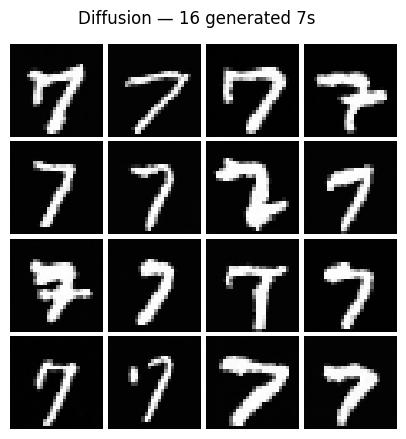

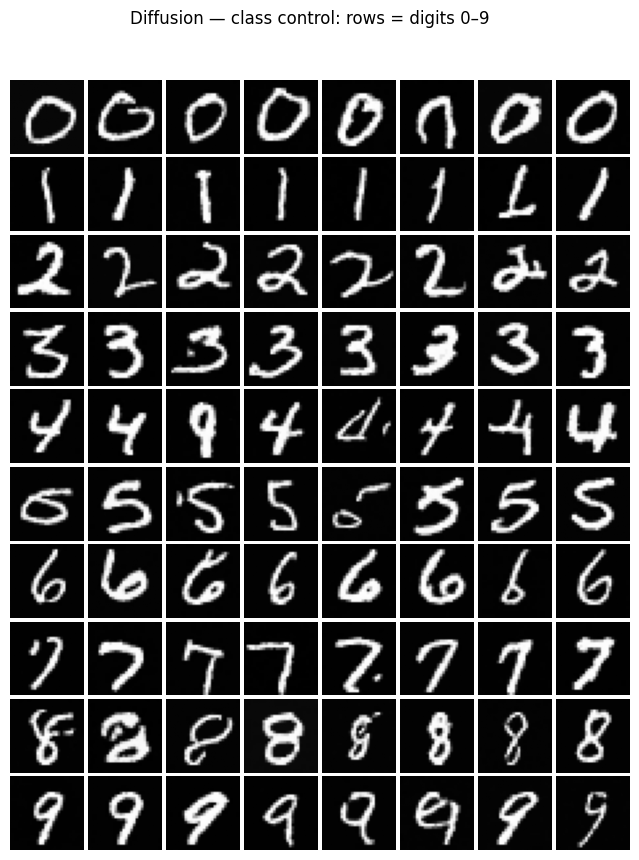

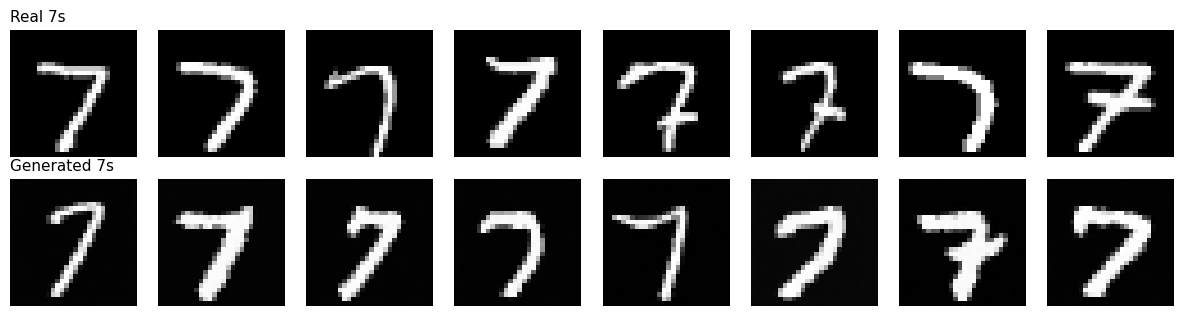

Saved to out_diffusion/


In [7]:
CHOSEN_DIGIT = 7  
def to_display(img):
    return (img.squeeze().cpu().numpy() + 1) / 2

def show_grid(imgs, nrow, ncol, title, filename, figsize):
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(nrow, ncol, wspace=0.05, hspace=0.05)
    for i, img in enumerate(imgs):
        ax = plt.subplot(gs[i]); ax.imshow(to_display(img), cmap="gray"); ax.axis("off")
    plt.suptitle(title, y=0.95)
    plt.savefig(os.path.join(OUT_DIR, filename), dpi=120, bbox_inches="tight")
    plt.show()

# (1) 4x4 of chosen digit
show_grid(
    sample(model, y=CHOSEN_DIGIT, n_samples=16), 4, 4,
    f"Diffusion — 16 generated {CHOSEN_DIGIT}s",
    f"grid_digit_{CHOSEN_DIGIT}.png", (5, 5),
)

# (2) 10x8 all digits
y_all = torch.arange(NUM_CLASSES, device=device).repeat_interleave(8)
show_grid(
    sample(model, y=y_all), NUM_CLASSES, 8,
    "Diffusion — class control: rows = digits 0–9",
    "grid_all_digits.png", (8, 10),
)

# (3) Real vs generated
real_imgs = []
for xr, yr in test_loader:
    real_imgs.append(xr[yr == CHOSEN_DIGIT])
    if sum(r.size(0) for r in real_imgs) >= 8:
        break
real_imgs = torch.cat(real_imgs)[:8]
gen_imgs = sample(model, y=CHOSEN_DIGIT, n_samples=8).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for col in range(8):
    axes[0, col].imshow(to_display(real_imgs[col]), cmap="gray"); axes[0, col].axis("off")
    axes[1, col].imshow(to_display(gen_imgs[col]),  cmap="gray"); axes[1, col].axis("off")
axes[0, 0].set_title(f"Real {CHOSEN_DIGIT}s",      loc="left", x=0, fontsize=11)
axes[1, 0].set_title(f"Generated {CHOSEN_DIGIT}s", loc="left", x=0, fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"real_vs_generated_{CHOSEN_DIGIT}.png"), dpi=120, bbox_inches="tight")
plt.show()

print(f"Saved to {OUT_DIR}/")

## How the Diffusion Model Works

The diffusion model is built around a simple two-part idea: first we deliberately corrupt an image, then we train a network to reverse that corruption. Once the network is good at reversing corruption, we can hand it pure noise and ask it to produce an image. The sections below walk through how each part of the code above contributes to this.

### 1. The forward process — adding noise to a digit

Starting from a clean MNIST digit, we add a small amount of Gaussian noise. We repeat this 1000 times, with the amount of noise growing slightly at each step. By the final step the original digit is gone and only random noise remains.

We don't actually loop 1000 times during training. There is a closed-form shortcut that lets us jump from the clean image directly to any noise level in one step, and that is what `q_sample` implements. The forward-diffusion plot earlier in the notebook shows this in action — the same digit at increasing noise levels until it becomes indistinguishable from random noise.

### 2. What the U-Net learns

The U-Net is not trained to draw digits. It is trained to do something simpler: given a noisy image, predict the noise that was added.

The training step works like this. We take a clean digit, pick a random noise level, add the corresponding noise, and ask the U-Net what noise it sees. We then compare the U-Net's prediction with the noise we actually added, and use the difference as the training signal. That is the entire training loop — one regression task, no adversary, no two networks fighting each other.

If the network can predict the noise, then by subtracting it we can recover the clean image. So learning to predict noise is equivalent to learning to denoise.

### 3. The reverse process — turning noise back into a digit

Generating a new digit follows directly from what the U-Net learned:

1. Start from pure random noise.
2. Ask the U-Net to predict the noise in the current image.
3. Subtract a small portion of that predicted noise.
4. Repeat for 1000 steps.

Each step the image is slightly less noisy and slightly closer to a real digit. The `sample` function implements this by walking from the highest noise level down to zero. The number of steps matches the forward process — we corrupted the image in 1000 small steps, so we reverse it in 1000 small steps.

### 4. Generating a specific digit

To generate a specific number rather than any random digit, we feed the digit label into the U-Net alongside the timestep. A small lookup table (`class_embed`) converts each label into a vector of features, and that vector is mixed into every layer of the U-Net through the time and class embedding. This is what allows `sample(model, y=7)` to reliably produce sevens. The CGAN uses the same idea — it also takes the label as an extra input — just plugged into a different network architecture.

### 5. Why it works

Each training example uses a randomly chosen digit, a randomly chosen noise level, and a fresh sample of noise. Across many training steps the U-Net sees the entire dataset corrupted at every level, which is what gives diffusion its broad coverage of the data. The training is stable because the loss is a single regression objective — there is no min-max game, no two networks pulling in opposite directions, and the loss curve goes down smoothly throughout training.


## Comparison with CGAN (Task 3)

Both generate MNIST digits conditioned on a label, but the underlying approaches are very different. The table below summarises the main contrasts.

| Aspect | CGAN | Stable Diffusion |
|---|---|---|
| Number of networks | Two — a Generator and a Discriminator trained against each other | One — a U-Net trained to predict noise |
| Inputs | A random vector and a digit label | A noisy image, a noise level, and a digit label |
| Training objective | Adversarial — the Generator tries to fool the Discriminator | Regression — predict the noise added to the image |
| Training stability | Sensitive — the two networks can become unbalanced or collapse | Stable — the loss decreases smoothly throughout training |
| Generation speed | Fast — one forward pass produces an image | Slow — around 1000 denoising steps per image |
| Sample diversity | Prone to mode collapse; can repeat the same style for a class | Naturally diverse; different runs produce different handwriting styles |
| How the label is used | Concatenated to the random vector before entering the Generator | Looked up in an embedding table and added into every layer of the U-Net |

**Tradeoff.** Once trained, the CGAN is much faster at generating images — a single forward pass against the diffusion model's 1000 steps. The diffusion model is the easier of the two to train: it produced reasonable digits within 50 epochs and a smooth loss curve, while the CGAN required 1000 epochs and careful balancing of the Generator and Discriminator to reach comparable quality.


## Main Difference Between GAN and Stable Diffusion

A **GAN** generates in **one shot** through an *adversarial game* between two networks: a Generator that tries to fool a Discriminator, and a Discriminator that tries to catch fakes. The two are trained jointly with a min–max objective. Sampling is a single forward pass and therefore very fast, but training is notoriously brittle (vanishing gradients, mode collapse, oscillation) and the model can ignore parts of the data distribution.

**Stable Diffusion** generates by **iterative denoising**. A single network is trained to predict the noise added to a clean image at a random timestep — purely a regression task with MSE loss. To sample, we start from pure Gaussian noise and run the denoising network $T$ times, peeling away noise step by step. This is much more stable to train (no adversary) and naturally covers the full data distribution (every noise level becomes a training example), at the cost of being $T$× slower at sampling.

**One-line summary:**

> **GAN = one-shot adversarial generation. Stable Diffusion = iterative likelihood-based denoising.**
>
> GANs trade stability for speed; diffusion trades speed for stability and diversity.
